<a href="https://colab.research.google.com/github/Aayush974/learning-pytorch/blob/main/03_custom_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting the data

The following code block downloads data from the [tutorial](https://www.learnpytorch.io/04_pytorch_custom_datasets/#1-get-data) i am following.
The dataset contains images of pizza, steak and sushi which is a subset of [Food101 dataset](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/)

In [45]:
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

data/pizza_steak_sushi directory exists.


In [46]:
import os
for dirpath,dirname,filename in os.walk(image_path):
    print(f"current path: {dirpath}")
    print(f"folders: {dirname}")
    print(f"images: {len(filename)}")

current path: data/pizza_steak_sushi
folders: ['test', 'train']
images: 0
current path: data/pizza_steak_sushi/test
folders: ['steak', 'sushi', 'pizza']
images: 0
current path: data/pizza_steak_sushi/test/steak
folders: []
images: 19
current path: data/pizza_steak_sushi/test/sushi
folders: []
images: 31
current path: data/pizza_steak_sushi/test/pizza
folders: []
images: 25
current path: data/pizza_steak_sushi/train
folders: ['steak', 'sushi', 'pizza']
images: 0
current path: data/pizza_steak_sushi/train/steak
folders: []
images: 75
current path: data/pizza_steak_sushi/train/sushi
folders: []
images: 72
current path: data/pizza_steak_sushi/train/pizza
folders: []
images: 78


we have 225 train images and 75 test images

## Visualizing the images

img class  steak
img width  512
img height  384


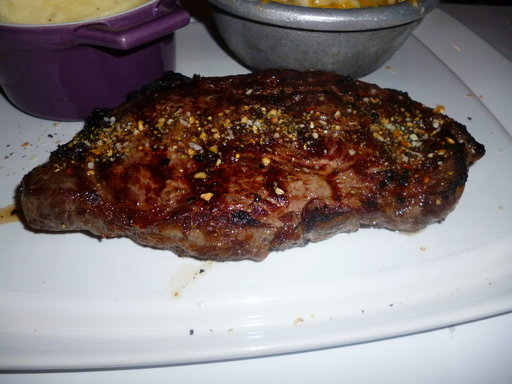

In [47]:
import random
from PIL import Image

image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image_path = random.choice(image_path_list)
img_class = random_image_path.parent.stem
img = Image.open(random_image_path)
print("img class ",img_class)
print("img width ",img.width)
print("img height ",img.height)
img

# Transforming the data

currently our data is in form of images , we need to convert them into tensors in order to work with them

In [48]:
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

data_transform = transforms.Compose( # create a group of transforms
    [
        transforms.Resize(size=(64,64)), # 1. resizing the images to 64x64 images
        transforms.RandomHorizontalFlip(p=0.5), # 2. flip the image horizontally with a 50% chance
        transforms.ToTensor() # 3. convert images to tensor
    ]
)

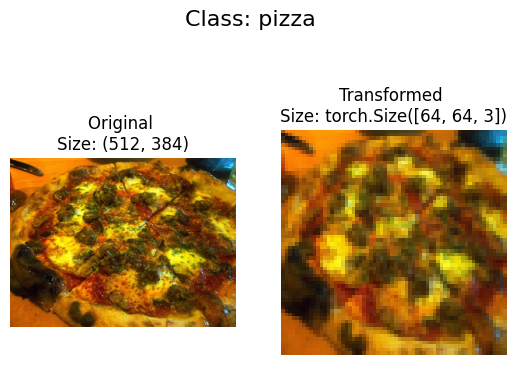

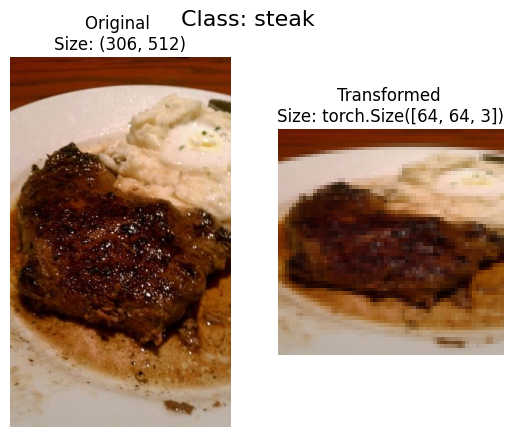

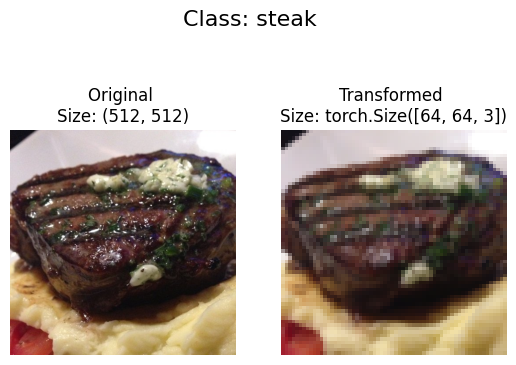

In [49]:
from matplotlib import pyplot as plt
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths.
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list,
                        transform=data_transform,
                        n=3)

# Loading image data

In [50]:
train_dir = image_path/"train"
test_dir = image_path/"test"
train_data = datasets.ImageFolder(
    root = train_dir,
    transform=data_transform,
    target_transform=None
)

test_data = datasets.ImageFolder(
    root = test_dir,
    transform=data_transform
)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


the ImageFolder methods scans the data in the specified root directory and create a dataset object from it.

Each subfolder inside the root directory becomes the class labels,
the class labels are arrangged alphabetically.
The files inside each subfolder are the actual data samples which belong to the class label of the parent directory

The transforms are applied dynamically whenever we access the data from the dataset

In [51]:
x,y = train_data[0]
class_names = train_data.classes
print(f"no. of samples in train data {len(train_data)}")
print(f"no. of samples in test data {len(test_data)}")
print(f"shape of an image: {x.shape}")
print(f"available class labels {train_data.class_to_idx}")

no. of samples in train data 225
no. of samples in test data 75
shape of an image: torch.Size([3, 64, 64])
available class labels {'pizza': 0, 'steak': 1, 'sushi': 2}


In [52]:
train_dataloader = DataLoader(train_data,batch_size=3,shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=3,shuffle=True)

train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c10d448cbf0>,
 <torch.utils.data.dataloader.DataLoader at 0x7c10d4033440>)

# Model 0 (without data augmentation)

let's create a tiny VGG model with minimal data augmentations (only resize and tensor transforms)

## create dataset and dataloader

In [53]:
simple_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [54]:
train_data_simple = datasets.ImageFolder(root=train_dir,transform=simple_transforms)
test_data_simple = datasets.ImageFolder(root=test_dir,transform=simple_transforms)

Batch_size = 32
num_workers = os.cpu_count() # how many subprocessors are used to load data

train_dataloader_simple = DataLoader(
    dataset=train_data_simple,
    batch_size=Batch_size,
    shuffle=True,
    num_workers=num_workers
    )
test_dataloader_simple = DataLoader(
    dataset=test_data_simple,
    batch_size=Batch_size,
    shuffle=False,
    num_workers=num_workers
)


## defining model

In [55]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"


class TinyVGG(nn.Module):
  def __init__(self,input_units,out_units,hidden_units):
      super().__init__()
      self.block1 = nn.Sequential(
          nn.Conv2d(
              in_channels=input_units,
              out_channels=hidden_units,
              kernel_size=3,
              padding="same",
              stride=1
          ),
          nn.ReLU(),
          nn.Conv2d(
              in_channels=hidden_units,
              out_channels=hidden_units,
              kernel_size=3,
              padding="same",
              stride=1
          ),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2) # default stride value is same as padding
      )

      self.block2 = nn.Sequential(
          nn.Conv2d(
              in_channels=hidden_units,
              out_channels=hidden_units,
              kernel_size=3,
              padding="same",
              stride=1
          ),
          nn.ReLU(),
          nn.Conv2d(
              in_channels=hidden_units,
              out_channels=hidden_units,
              kernel_size=3,
              padding="same",
              stride=1
          ),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2) # default stride value is same as padding
      )

      self.classifier = nn.Sequential(
          nn.Flatten(),
          nn.Linear(in_features=hidden_units*16*16,out_features=out_units)
      )

  def forward(self,x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.classifier(x)
    return x

model_0 = TinyVGG(input_units=3, # number of color channels (3 for RGB)
                  hidden_units=10,
                  out_units=len(train_data.classes)).to(device)
model_0

TinyVGG(
  (block1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

## testing model

In [56]:

# 1. Get a batch of images and labels from the DataLoader
img_batch, label_batch = next(iter(train_dataloader_simple))

# 2. Get a single image from the batch and unsqueeze the image so its shape fits the model
img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

# 3. Perform a forward pass on a single image
model_0.eval()
with torch.inference_mode():
    pred = model_0(img_single.to(device))

# 4. Print out what's happening and convert model logits -> pred probs -> pred label
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 64, 64])

Output logits:
tensor([[ 0.0171, -0.0024,  0.0003]], device='cuda:0')

Output prediction probabilities:
tensor([[0.3374, 0.3309, 0.3317]], device='cuda:0')

Output prediction label:
tensor([0], device='cuda:0')

Actual label:
1


## getting model summary with torchinfo

torchinfo is a usefull library and offers a summary method with which we can see how our input data changes as it moves through the model and other informations about the model

In [57]:
# Install torchinfo if it's not available, import it if it is
try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary
summary(model_0, input_size=[32, 3, 64, 64]) # do a test pass through of an example input size

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 3]                   --
├─Sequential: 1-1                        [32, 10, 32, 32]          --
│    └─Conv2d: 2-1                       [32, 10, 64, 64]          280
│    └─ReLU: 2-2                         [32, 10, 64, 64]          --
│    └─Conv2d: 2-3                       [32, 10, 64, 64]          910
│    └─ReLU: 2-4                         [32, 10, 64, 64]          --
│    └─MaxPool2d: 2-5                    [32, 10, 32, 32]          --
├─Sequential: 1-2                        [32, 10, 16, 16]          --
│    └─Conv2d: 2-6                       [32, 10, 32, 32]          910
│    └─ReLU: 2-7                         [32, 10, 32, 32]          --
│    └─Conv2d: 2-8                       [32, 10, 32, 32]          910
│    └─ReLU: 2-9                         [32, 10, 32, 32]          --
│    └─MaxPool2d: 2-10                   [32, 10, 16, 16]          --
├─Sequentia

## defining train and test step functions

In [58]:
def train_step(
    model:torch.nn.Module,
    dataloader:torch.utils.data.DataLoader,
    loss_fn:torch.nn.Module,
    optimizer:torch.optim.Optimizer,
    device:torch.device=device
):
  model.train()
  train_loss , train_acc= 0,0

  for batch,(x,y) in enumerate(dataloader):
    x,y = x.to(device),y.to(device)
    y_preds = model(x)

    loss =  loss_fn(y_preds,y)
    train_loss = train_loss + loss.item()

    y_pred_labels = torch.argmax(torch.softmax(y_preds,dim=1),dim=1)
    acc = (torch.eq(y,y_pred_labels).sum().item())/len(y)*100
    train_acc = train_acc + acc

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss = train_loss/len(dataloader)
  train_acc = train_acc/len(dataloader)
  return train_loss,train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device:torch.device=device
  ):
    # Put model in eval mode
    model.eval()
    test_loss, test_acc = 0, 0

    with torch.inference_mode():

        for batch, (x, y) in enumerate(dataloader):
            x, y = x.to(device), y.to(device)
            test_preds = model(x)


            loss = loss_fn(test_preds, y)
            test_loss += loss.item()


            y_pred_labels = torch.argmax(torch.softmax(test_preds,dim=1),dim=1)
            acc = (torch.eq(y,y_pred_labels).sum().item())/len(y)*100
            test_acc = test_acc + acc


    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


In [59]:
from tqdm.auto import tqdm

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

## evaluating model 0

In [38]:
torch.manual_seed(42)
from timeit import default_timer as Timer

NUM_EPOCHS = 5
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),lr = 0.001)

start_timer = Timer()
model0_results = train(
    model_0,
    train_dataloader_simple,
    test_dataloader_simple,
    optimizer,
    loss_fn,
    NUM_EPOCHS
)

end_timer = Timer()

print(f"model took {end_timer-start_timer} seconds")

Epoch: 1 | train_loss: 1.1048 | train_acc: 25.0000 | test_loss: 1.0959 | test_acc: 29.0720
Epoch: 2 | train_loss: 1.0897 | train_acc: 42.1875 | test_loss: 1.1088 | test_acc: 26.0417
Epoch: 3 | train_loss: 1.0813 | train_acc: 42.5781 | test_loss: 1.1322 | test_acc: 26.0417
Epoch: 4 | train_loss: 1.1162 | train_acc: 30.4688 | test_loss: 1.1456 | test_acc: 26.0417
Epoch: 5 | train_loss: 1.0835 | train_acc: 42.5781 | test_loss: 1.1360 | test_acc: 26.0417
model took 5.831341322000014 seconds


## creating a loss curve visualizer function

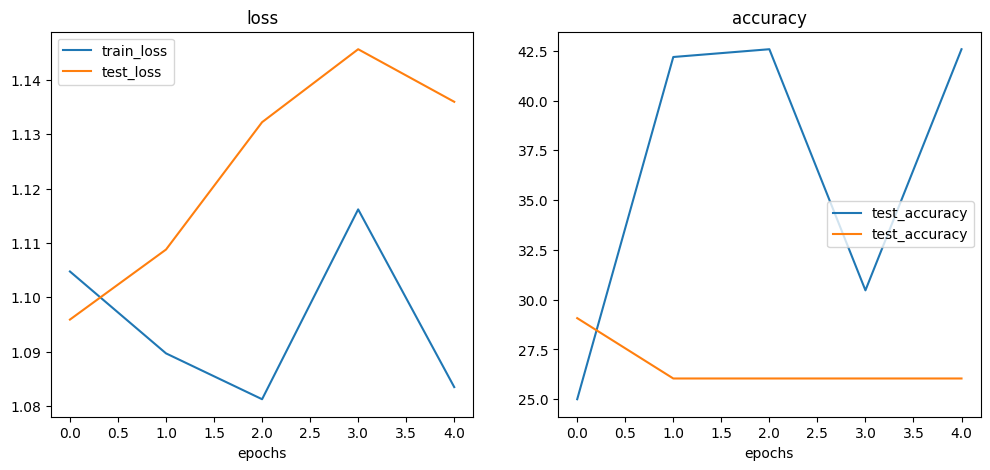

In [39]:
from ast import Dict
from matplotlib import pyplot as plt

def plot_losscurve(
    results:Dict
):
  epochs = range(len(model0_results["train_loss"]))

  loss = results["train_loss"]
  test_loss = results["test_loss"]

  accuracy = results["train_acc"]
  test_accuracy = results["test_acc"]

  plt.figure(figsize=(12,5))

  plt.subplot(1,2,1)
  plt.plot(epochs,loss,label="train_loss")
  plt.plot(epochs,test_loss,label="test_loss")
  plt.title("loss")
  plt.xlabel("epochs")
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(epochs,accuracy,label="test_accuracy")
  plt.plot(epochs,test_accuracy,label="test_accuracy")
  plt.title("accuracy")
  plt.xlabel("epochs")
  plt.legend()

plot_losscurve(model0_results)

welp, the graph is all over the place

# Overfitting v/s Underfitting

An **overfitting** model is one that performs better (often by a considerable margin) on the training set than the validation/test set.
If your training loss is far lower than your test loss, your model is overfitting.

The other side is when your training and test loss are not as low as you'd like, this is considered <b>underfitting</b>.

The ideal position for a training and test loss curve is for them to line up closely with each other.

# Model 1 (with data augmentation)

## create datasets and dataoaders

In [40]:
# define transforms
train_transforms_trivialAugment = transforms.Compose(
    [
        transforms.Resize(size=(64,64)),
        transforms.TrivialAugmentWide(num_magnitude_bins=31),
        transforms.ToTensor()
    ]
)

test_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

# create datasets from ImageFolder method
train_data_augmented = datasets.ImageFolder(
    root=train_dir,
    transform=train_transforms_trivialAugment
)
test_data_simple = datasets.ImageFolder(
    root=test_dir,
    transform=test_transforms
)


In [41]:
# create dataloader

train_dataloader_augmented = DataLoader(
    train_data_augmented,
    batch_size=32,
    num_workers=os.cpu_count(),
    shuffle=True
)

test_dataloader_simple = DataLoader(
    test_data_simple,
    batch_size=32,
    num_workers=os.cpu_count(),
    shuffle=False
)

## training model

In [42]:
model_1 = TinyVGG(
    input_units=3,
    hidden_units=10,
    out_units=3
).to(device)
model_1

TinyVGG(
  (block1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [43]:

epochs = 5
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),lr=0.001)

start_timer = Timer()
model_1_results = train(
    model_1,
    train_dataloader=train_dataloader_augmented,
    test_dataloader=test_dataloader_simple,
    loss_fn=loss_fn,
    optimizer = optimizer,
    epochs = epochs
)

end_timer = Timer()

print(f"model 1 took {end_timer-start_timer} seconds")


Epoch: 1 | train_loss: 1.1146 | train_acc: 28.5156 | test_loss: 1.1064 | test_acc: 26.0417
Epoch: 2 | train_loss: 1.1145 | train_acc: 32.4219 | test_loss: 1.1386 | test_acc: 19.7917
Epoch: 3 | train_loss: 1.1045 | train_acc: 29.2969 | test_loss: 1.1108 | test_acc: 19.7917
Epoch: 4 | train_loss: 1.0961 | train_acc: 30.4688 | test_loss: 1.0931 | test_acc: 57.2917
Epoch: 5 | train_loss: 1.0910 | train_acc: 41.0156 | test_loss: 1.0778 | test_acc: 54.1667
model 1 took 4.6690436389999945 seconds


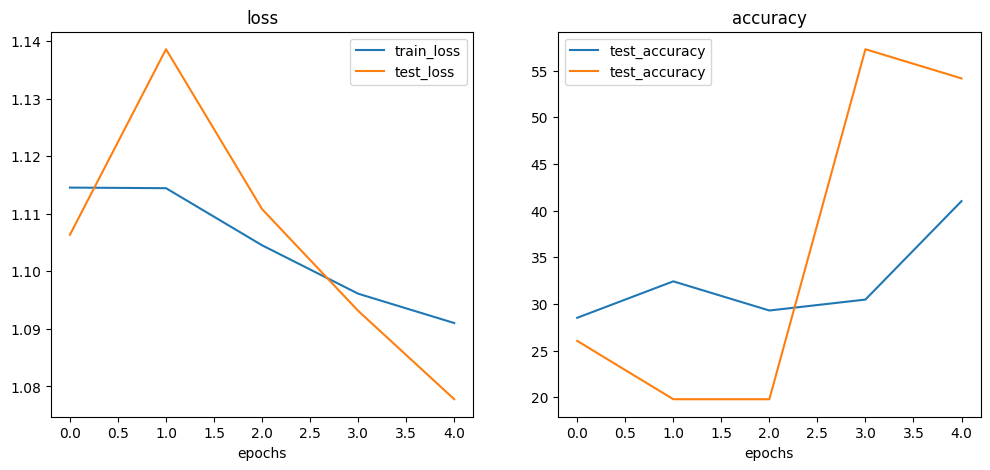

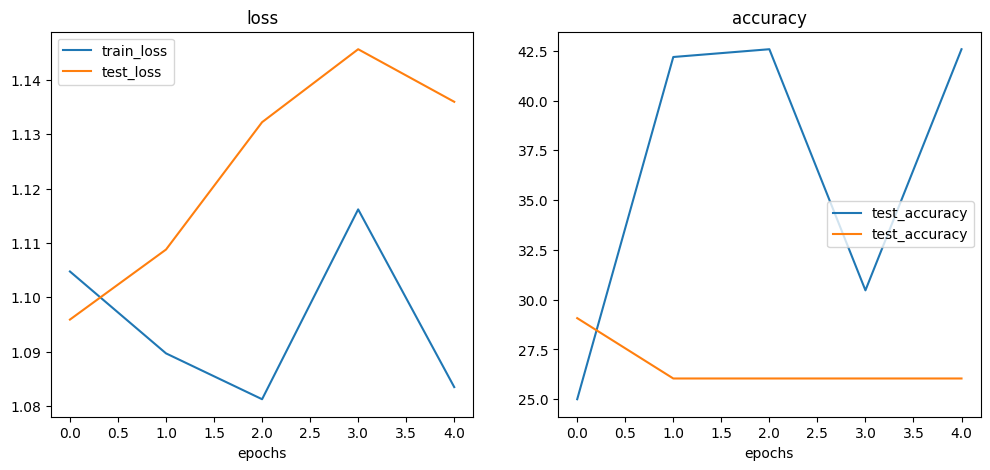

In [44]:
plot_losscurve(model_1_results)
plot_losscurve(model0_results)

the results of both the model dosen't seem very good, they are all over the place